In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
df = pd.read_csv("stocks.csv")

# Show data
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [3]:
# Dataset info
df.info()

# Check null values
df.isnull().sum()

# Fill or drop missing values
df.dropna(inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values(by='Date')

<class 'pandas.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    str    
 1   Date       248 non-null    str    
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 19.0 KB


In [4]:
# Daily return
df['Daily Return'] = df['Close'].pct_change()

# Moving averages
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Daily Return,MA_10,MA_50
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600,NaN,NaN,NaN
62,MSFT,2023-02-07,260.529999,268.769989,260.079987,267.559998,266.891510,50841400,0.730100,NaN,NaN
186,GOOG,2023-02-07,103.629997,108.669998,103.547997,108.040001,108.040001,33738800,-0.596203,NaN,NaN
124,NFLX,2023-02-07,358.510010,364.179993,354.179993,362.950012,362.950012,6289400,2.359404,NaN,NaN
187,GOOG,2023-02-08,102.690002,103.580002,98.455002,100.000000,100.000000,73546000,-0.724480,NaN,NaN


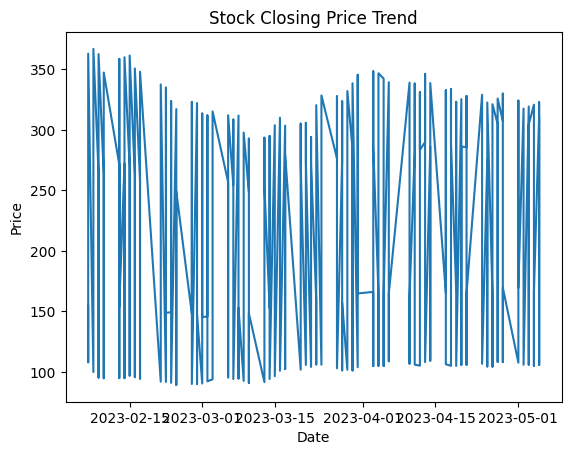

In [5]:
plt.figure()
plt.plot(df['Date'], df['Close'])
plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

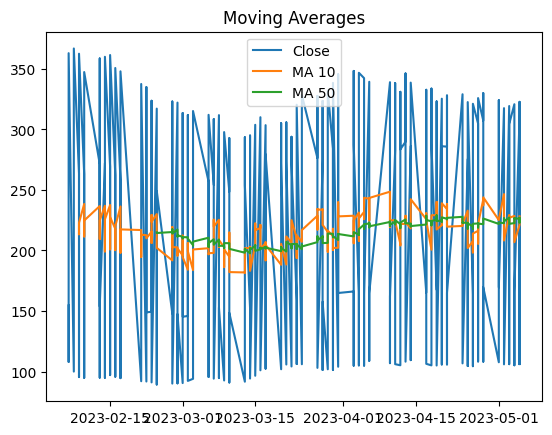

In [6]:
plt.figure()
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_10'], label='MA 10')
plt.plot(df['Date'], df['MA_50'], label='MA 50')
plt.legend()
plt.title("Moving Averages")
plt.show()

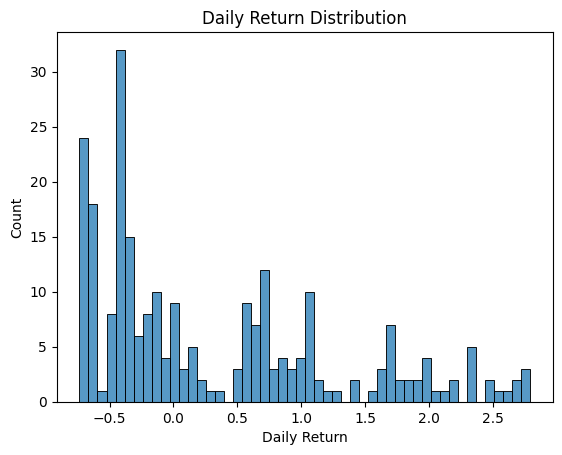

In [7]:
plt.figure()
sns.histplot(df['Daily Return'].dropna(), bins=50)
plt.title("Daily Return Distribution")
plt.show()

In [8]:
# Volatility
volatility = df['Daily Return'].std()
print("Volatility:", volatility)

# Average return
avg_return = df['Daily Return'].mean()
print("Average Return:", avg_return)

Volatility: 0.9584126443596678
Average Return: 0.3142508589591466


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Feature & target
df['Days'] = np.arange(len(df))

X = df[['Days']]
y = df['Close']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

print("Model Score:", model.score(X_test, y_test))

Model Score: -0.13478605953280343


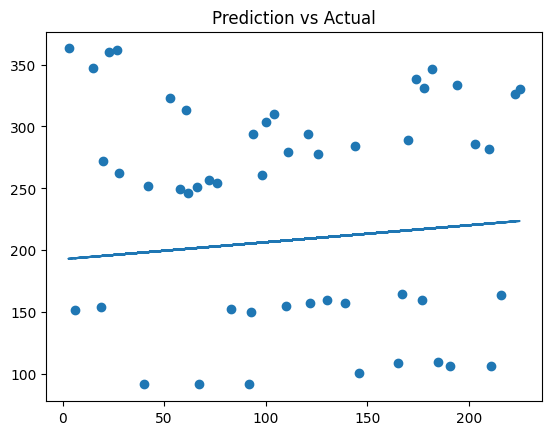

In [12]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, pred)
plt.title("Prediction vs Actual")
plt.show()

In [14]:
import streamlit as st
import pandas as pd

df = pd.read_csv("stocks.csv")

st.title("Stock Dashboard")

st.line_chart(df['Close'])

st.write(df.describe())

2026-04-25 11:17:17.768 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 11:17:17.901 
  command:

    streamlit run C:\Users\akuma\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-25 11:17:17.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 11:17:17.902 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 11:17:19.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 11:17:19.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 11:17:19.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 11:17: